# Kelp2 - UAS PBA: Multilabel Text Classification ABSA

Notebook ini mengerjakan **Proyek A - Multilabel Text Classification ABSA** dari review Google Places.  
Tujuannya adalah memprediksi satu atau lebih label ABSA pada level review, misalnya `PRODUCT_POSITIVE`, `PRICE_POSITIVE`, `PLACE_NEGATIVE`, `PROMOTION_NEUTRAL`, atau `OUT_OF_TOPIC`.

Notebook sengaja dibuat bertahap seperti guided notebook:
1. data loading dan validasi dataset,
2. preprocessing dan label engineering,
3. EDA dan visualisasi label,
4. feature engineering / representasi teks,
5. training beberapa model dan tuning sederhana,
6. evaluasi test set,
7. confusion matrix per label,
8. error analysis,
9. penyimpanan model terbaik,
10. contoh inferensi dan hubungan dengan output NER.

## 0. Pemetaan terhadap ketentuan soal UAS

Bagian notebook ini disusun langsung mengikuti rubrik Proyek A:

| Kriteria UAS | Implementasi pada notebook |
|---|---|
| Data loading dan validasi | Membaca `Kelp2_multilabel_train.csv`, `val`, `test`, menampilkan contoh data, memvalidasi kolom teks dan label 0/1. |
| Preprocessing dan label engineering | Cleaning teks, normalisasi huruf kecil, encoding multilabel dari kolom label biner, dan menggunakan split train/validation/test. |
| EDA dan visualisasi | Distribusi panjang review, jumlah token, distribusi label ABSA, dan correlation matrix antar label. |
| Representasi teks | Membandingkan TF-IDF word unigram-bigram dan Bag of Words unigram-bigram. |
| Model training | Membandingkan Binary Relevance/OneVsRest dan Classifier Chain dengan Logistic Regression dan Linear SVM. |
| Evaluasi | Classification report per label, micro/macro/weighted-F1, Hamming Loss, subset accuracy, dan confusion matrix per label. |
| Deployment | Model terbaik disimpan dalam `.joblib` dan dipakai oleh aplikasi Streamlit. |

## 1. Import library dan konfigurasi path

Cell ini menyiapkan library utama. `scikit-learn` digunakan untuk pemodelan multilabel karena ringan, mudah direplikasi, dan cocok untuk baseline yang kuat pada dataset teks berukuran kecil-menengah. Path dibuat fleksibel supaya notebook tetap bisa dijalankan dari folder `project/` maupun dari folder `project/notebook/`.

In [1]:
from pathlib import Path
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    f1_score,
    hamming_loss,
    accuracy_score,
    confusion_matrix,
)

# Agar path aman ketika notebook dijalankan dari project/ atau project/notebook/
CWD = Path.cwd()
if (CWD / 'dataset').exists():
    ROOT = CWD
elif (CWD.parent / 'dataset').exists():
    ROOT = CWD.parent
else:
    ROOT = Path('..')

DATA_DIR = ROOT / 'dataset'
RESULTS_DIR = ROOT / 'results'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'figures'

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT.resolve())
print('Dataset dir :', DATA_DIR.resolve())

Project root: /mnt/data/Projek_UAS_PBA_Kelas_Kelp2
Dataset dir : /mnt/data/Projek_UAS_PBA_Kelas_Kelp2/dataset


## 2. Skema label ABSA

Dataset UAS memakai **13 label multilabel**. Empat aspek utama adalah `PRODUCT`, `PRICE`, `PLACE`, dan `PROMOTION`; masing-masing aspek dapat memiliki sentimen `POSITIVE`, `NEGATIVE`, atau `NEUTRAL`. Label `OUT_OF_TOPIC` digunakan saat review tidak relevan dengan empat aspek tersebut.

In [2]:
LABELS = [
    'PRODUCT_POSITIVE', 'PRODUCT_NEGATIVE', 'PRODUCT_NEUTRAL',
    'PRICE_POSITIVE', 'PRICE_NEGATIVE', 'PRICE_NEUTRAL',
    'PLACE_POSITIVE', 'PLACE_NEGATIVE', 'PLACE_NEUTRAL',
    'PROMOTION_POSITIVE', 'PROMOTION_NEGATIVE', 'PROMOTION_NEUTRAL',
    'OUT_OF_TOPIC'
]

label_info = pd.DataFrame({
    'label': LABELS,
    'aspect': [x.split('_')[0] if x != 'OUT_OF_TOPIC' else 'OUT_OF_TOPIC' for x in LABELS],
    'sentiment': [x.split('_')[-1] if x != 'OUT_OF_TOPIC' else '-' for x in LABELS],
})
display(label_info)

,label,aspect,sentiment
0,PRODUCT_POSITIVE,PRODUCT,POSITIVE
1,PRODUCT_NEGATIVE,PRODUCT,NEGATIVE
2,PRODUCT_NEUTRAL,PRODUCT,NEUTRAL
3,PRICE_POSITIVE,PRICE,POSITIVE
4,PRICE_NEGATIVE,PRICE,NEGATIVE
5,PRICE_NEUTRAL,PRICE,NEUTRAL
6,PLACE_POSITIVE,PLACE,POSITIVE
7,PLACE_NEGATIVE,PLACE,NEGATIVE
8,PLACE_NEUTRAL,PLACE,NEUTRAL
9,PROMOTION_POSITIVE,PROMOTION,POSITIVE


## 3. Data loading train/validation/test

Cell ini membaca dataset split untuk klasifikasi multilabel. Split sudah disediakan agar eksperimen konsisten antara model dan agar evaluasi akhir hanya dilakukan pada test set.

In [3]:
train_df = pd.read_csv(DATA_DIR / 'Kelp2_multilabel_train.csv')
val_df = pd.read_csv(DATA_DIR / 'Kelp2_multilabel_val.csv')
test_df = pd.read_csv(DATA_DIR / 'Kelp2_multilabel_test.csv')

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'jumlah_review': [len(train_df), len(val_df), len(test_df)],
    'jumlah_kolom': [train_df.shape[1], val_df.shape[1], test_df.shape[1]],
})
display(split_summary)

display(train_df.head(5))

,split,jumlah_review,jumlah_kolom
0,train,2440,16
1,validation,305,16
2,test,305,16


,id,text,label_list,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
0,0,tempatnya aestetic sekali lebih dekat dari rum...,PLACE_POSITIVE,0,0,0,0,0,0,1,0,0,0,0,0,0
1,1,duh harus berkata apa lg yah klo ada bintang d...,PRODUCT_POSITIVE,1,0,0,0,0,0,0,0,0,0,0,0,0
2,2,bb 73 tb 170 aku suka modelnya panjangnya pas ...,PRODUCT_POSITIVE|PRICE_POSITIVE,1,0,0,1,0,0,0,0,0,0,0,0,0
3,3,bahan nya tebal sesuai sama yg di foto,PRODUCT_POSITIVE,1,0,0,0,0,0,0,0,0,0,0,0,0
4,4,first time kesini tempatnya comfy dan luas jg ...,PRODUCT_POSITIVE|PLACE_POSITIVE,1,0,0,0,0,0,1,0,0,0,0,0,0


## 4. Validasi struktur dataset

Validasi dilakukan sebelum modeling supaya error data tidak ikut terbawa ke model. Hal yang dicek:
- kolom `text` harus ada,
- semua kolom label harus ada,
- nilai label harus biner 0/1,
- tidak ada teks kosong,
- setiap review minimal memiliki satu label.

In [4]:
def validate_multilabel_dataframe(df: pd.DataFrame, split_name: str) -> dict:
    missing_columns = [c for c in ['text'] + LABELS if c not in df.columns]
    if missing_columns:
        raise ValueError(f'{split_name}: kolom hilang: {missing_columns}')

    # Cek nilai label hanya 0/1
    invalid_label_values = {}
    for label in LABELS:
        values = set(df[label].dropna().unique().tolist())
        if not values.issubset({0, 1}):
            invalid_label_values[label] = values
    if invalid_label_values:
        raise ValueError(f'{split_name}: nilai label tidak biner: {invalid_label_values}')

    empty_text = df['text'].isna().sum() + (df['text'].astype(str).str.strip() == '').sum()
    rows_without_label = (df[LABELS].sum(axis=1) == 0).sum()

    return {
        'split': split_name,
        'rows': len(df),
        'empty_text_rows': int(empty_text),
        'rows_without_label': int(rows_without_label),
        'duplicate_text_rows': int(df['text'].duplicated().sum()),
    }

validation_report = pd.DataFrame([
    validate_multilabel_dataframe(train_df, 'train'),
    validate_multilabel_dataframe(val_df, 'validation'),
    validate_multilabel_dataframe(test_df, 'test'),
])
display(validation_report)

,split,rows,empty_text_rows,rows_without_label,duplicate_text_rows
0,train,2440,0,0,1378
1,validation,305,0,0,29
2,test,305,0,0,26


## 5. Preprocessing teks

Review Google Places biasanya mengandung huruf besar-kecil tidak konsisten, tanda baca berlebih, angka, URL, emoji, dan spasi ganda. Cleaning yang digunakan bersifat konservatif agar makna review tetap terjaga:
- lowercase,
- hapus URL,
- hapus karakter selain huruf/angka/spasi/underscore/hyphen,
- rapikan spasi.

Stopword tidak dihapus karena kata pendek seperti `tidak`, `ga`, `kurang`, dan `murah` penting untuk sentimen.

In [5]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^0-9a-zA-Z_\-\s]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for df in [train_df, val_df, test_df]:
    df['text_clean'] = df['text'].apply(clean_text)
    df['char_length'] = df['text_clean'].str.len()
    df['word_count'] = df['text_clean'].str.split().apply(len)

comparison = train_df[['text', 'text_clean']].head(5)
display(comparison)

,text,text_clean
0,tempatnya aestetic sekali lebih dekat dari rum...,tempatnya aestetic sekali lebih dekat dari rum...
1,duh harus berkata apa lg yah klo ada bintang d...,duh harus berkata apa lg yah klo ada bintang d...
2,bb 73 tb 170 aku suka modelnya panjangnya pas ...,bb 73 tb 170 aku suka modelnya panjangnya pas ...
3,bahan nya tebal sesuai sama yg di foto,bahan nya tebal sesuai sama yg di foto
4,first time kesini tempatnya comfy dan luas jg ...,first time kesini tempatnya comfy dan luas jg ...


## 6. Label engineering dan penyiapan X-y

Format multilabel diubah menjadi matriks biner `y` berukuran `(jumlah_review, jumlah_label)`. Satu review bisa memiliki lebih dari satu nilai 1, misalnya review yang memuji produk sekaligus harga.

In [6]:
X_train = train_df['text_clean'].tolist()
X_val = val_df['text_clean'].tolist()
X_test = test_df['text_clean'].tolist()

y_train = train_df[LABELS].astype(int).values
y_val = val_df[LABELS].astype(int).values
y_test = test_df[LABELS].astype(int).values

print('X_train:', len(X_train), '| y_train:', y_train.shape)
print('X_val  :', len(X_val), '| y_val  :', y_val.shape)
print('X_test :', len(X_test), '| y_test :', y_test.shape)

label_cardinality = y_train.sum(axis=1).mean()
label_density = label_cardinality / len(LABELS)
print(f'Label cardinality train: {label_cardinality:.3f}')
print(f'Label density train    : {label_density:.3f}')

X_train: 2440 | y_train: (2440, 13)
X_val  : 305 | y_val  : (305, 13)
X_test : 305 | y_test : (305, 13)
Label cardinality train: 1.509
Label density train    : 0.116


## 7. Strategi penanganan label imbalance

Dataset ABSA biasanya tidak seimbang: label positif produk/tempat jauh lebih banyak daripada label promosi atau netral. Strategi yang digunakan:
1. memakai `class_weight='balanced'` pada Logistic Regression dan Linear SVM,
2. mengevaluasi dengan macro-F1 selain micro-F1 agar label minoritas ikut terlihat,
3. menampilkan confusion matrix per label untuk melihat false positive dan false negative tiap label.

In [7]:
label_distribution = train_df[LABELS].sum().sort_values(ascending=False).reset_index()
label_distribution.columns = ['label', 'positive_count_train']
label_distribution['percentage_train'] = label_distribution['positive_count_train'] / len(train_df) * 100
display(label_distribution)

,label,positive_count_train,percentage_train
0,PRODUCT_POSITIVE,1768,72.459016
1,PLACE_POSITIVE,837,34.303279
2,PRICE_POSITIVE,435,17.827869
3,OUT_OF_TOPIC,217,8.893443
4,PRODUCT_NEGATIVE,192,7.868852
5,PLACE_NEGATIVE,92,3.770492
6,PROMOTION_POSITIVE,48,1.967213
7,PRODUCT_NEUTRAL,45,1.844262
8,PRICE_NEGATIVE,18,0.737705
9,PRICE_NEUTRAL,17,0.696721


## 8. EDA 1 - Distribusi panjang review

Visualisasi panjang review membantu menentukan representasi teks dan batasan fitur. Review pendek biasanya hanya memuat satu aspek, sedangkan review panjang dapat berisi banyak aspek sekaligus.

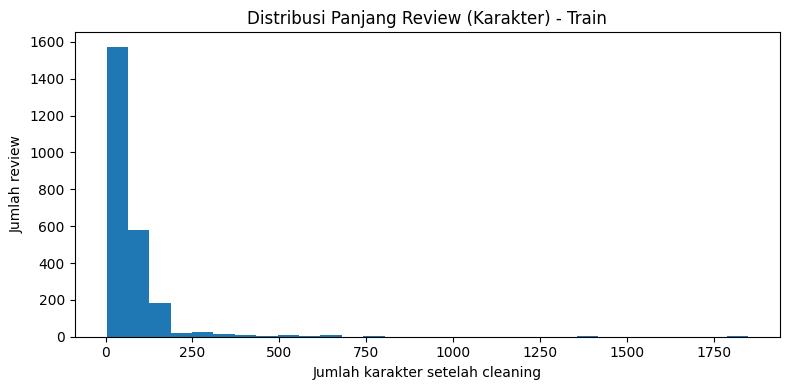

,char_length,word_count
count,2440.000000,2440.000000
mean,76.710246,12.304508
std,104.871315,16.645260
min,3.000000,1.000000
25%,35.000000,6.000000
50%,50.000000,8.000000
75%,83.000000,13.000000
max,1848.000000,262.000000


In [8]:
plt.figure(figsize=(8, 4))
plt.hist(train_df['char_length'], bins=30)
plt.title('Distribusi Panjang Review (Karakter) - Train')
plt.xlabel('Jumlah karakter setelah cleaning')
plt.ylabel('Jumlah review')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_length_distribution.png', dpi=150)
plt.show()

train_df[['char_length', 'word_count']].describe()

## 9. EDA 2 - Distribusi jumlah kata/token

Jumlah token digunakan untuk melihat variasi panjang teks. Pada pendekatan BoW/TF-IDF, token yang terlalu jarang biasanya tidak terlalu membantu, sehingga `max_features` dibatasi agar model tidak terlalu sparse.

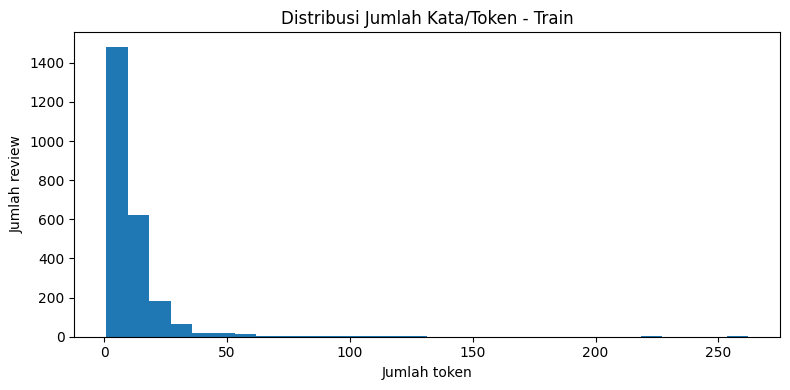

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(train_df['word_count'], bins=30)
plt.title('Distribusi Jumlah Kata/Token - Train')
plt.xlabel('Jumlah token')
plt.ylabel('Jumlah review')
plt.tight_layout()
plt.show()

## 10. EDA 3 - Distribusi label ABSA

Grafik ini menunjukkan label mana yang dominan dan label mana yang minoritas. Informasi ini dipakai saat membaca hasil macro-F1 dan error analysis.

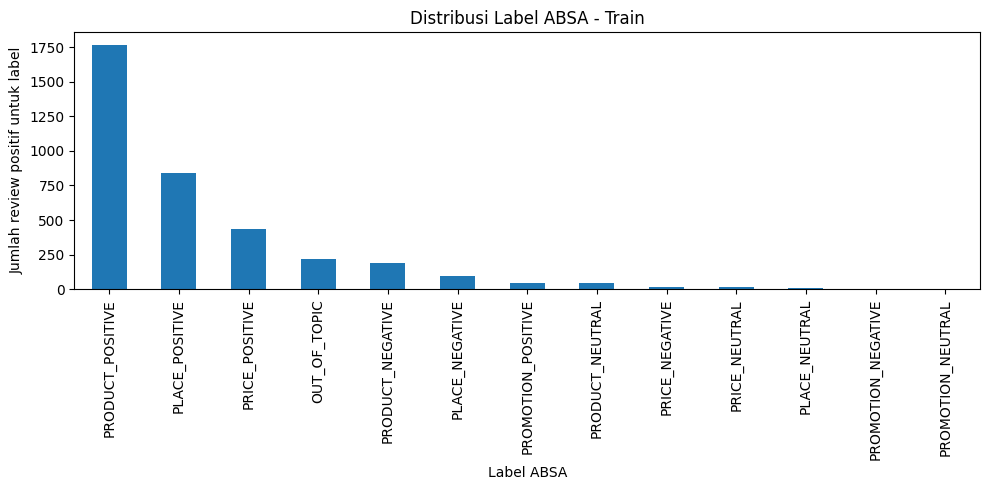

In [10]:
plt.figure(figsize=(10, 5))
train_df[LABELS].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Distribusi Label ABSA - Train')
plt.xlabel('Label ABSA')
plt.ylabel('Jumlah review positif untuk label')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multilabel_label_distribution.png', dpi=150)
plt.show()

## 11. EDA 4 - Correlation matrix antar label

Correlation matrix membantu membaca hubungan antar label. Misalnya, review yang memuji tempat bisa saja sekaligus memuji produk. Korelasi tidak digunakan langsung sebagai fitur, tetapi berguna untuk menjelaskan mengapa Classifier Chain dapat bermanfaat karena mempertimbangkan dependensi antar label.

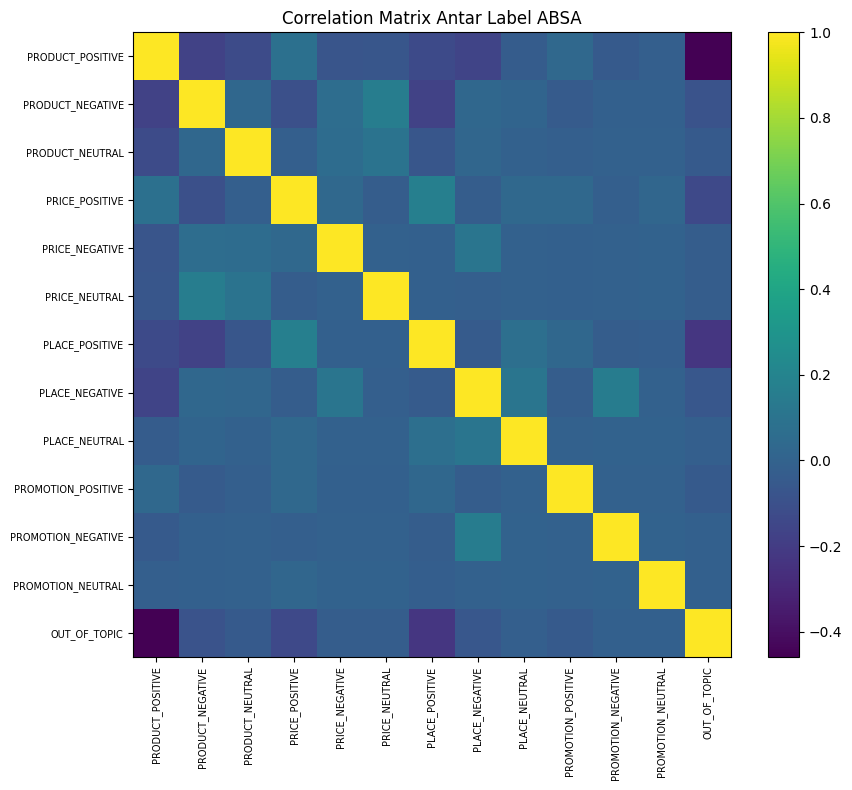

,PRODUCT_POSITIVE,PRODUCT_NEGATIVE,PRODUCT_NEUTRAL,PRICE_POSITIVE,PRICE_NEGATIVE,PRICE_NEUTRAL,PLACE_POSITIVE,PLACE_NEGATIVE,PLACE_NEUTRAL,PROMOTION_POSITIVE,PROMOTION_NEGATIVE,PROMOTION_NEUTRAL,OUT_OF_TOPIC
PRODUCT_POSITIVE,1.00,-0.17,-0.13,0.08,-0.08,-0.07,-0.13,-0.16,-0.04,0.03,-0.04,-0.01,-0.46
PRODUCT_NEGATIVE,-0.17,1.00,0.03,-0.10,0.06,0.16,-0.17,0.03,0.01,-0.04,-0.01,-0.01,-0.09
PRODUCT_NEUTRAL,-0.13,0.03,1.00,-0.02,0.06,0.10,-0.07,0.02,-0.01,-0.02,-0.01,-0.00,-0.04
PRICE_POSITIVE,0.08,-0.10,-0.02,1.00,0.03,-0.03,0.17,-0.03,0.04,0.03,-0.02,0.02,-0.14
PRICE_NEGATIVE,-0.08,0.06,0.06,0.03,1.00,-0.01,-0.01,0.11,-0.00,-0.01,-0.00,-0.00,-0.03
PRICE_NEUTRAL,-0.07,0.16,0.10,-0.03,-0.01,1.00,-0.01,-0.02,-0.00,-0.01,-0.00,-0.00,-0.03
PLACE_POSITIVE,-0.13,-0.17,-0.07,0.17,-0.01,-0.01,1.00,-0.04,0.07,0.03,-0.03,-0.02,-0.23
PLACE_NEGATIVE,-0.16,0.03,0.02,-0.03,0.11,-0.02,-0.04,1.00,0.11,-0.03,0.15,-0.01,-0.06
PLACE_NEUTRAL,-0.04,0.01,-0.01,0.04,-0.00,-0.00,0.07,0.11,1.00,-0.01,-0.00,-0.00,-0.02
PROMOTION_POSITIVE,0.03,-0.04,-0.02,0.03,-0.01,-0.01,0.03,-0.03,-0.01,1.00,-0.01,-0.00,-0.04


In [11]:
corr = train_df[LABELS].corr().fillna(0)
plt.figure(figsize=(9, 8))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(LABELS)), LABELS, rotation=90, fontsize=7)
plt.yticks(range(len(LABELS)), LABELS, fontsize=7)
plt.colorbar()
plt.title('Correlation Matrix Antar Label ABSA')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'label_correlation_matrix.png', dpi=150)
plt.show()

display(corr.round(2))

## 12. Feature engineering / representasi teks

Dua representasi teks dibandingkan:

1. **TF-IDF word unigram-bigram**  
   Memberi bobot lebih tinggi pada kata/frasa yang khas dan lebih rendah pada kata yang terlalu umum.

2. **Bag of Words unigram-bigram**  
   Menggunakan frekuensi kemunculan token/frasa. Representasi ini sederhana tetapi sering kuat pada dataset review.

Keduanya memakai n-gram `(1,2)` agar frasa seperti `harga murah`, `tempat nyaman`, dan `bahan bagus` dapat tertangkap.

In [12]:
def make_tfidf_logreg(C: float = 1.0) -> Pipeline:
    return Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=6000, ngram_range=(1, 2), min_df=1)),
        ('classifier', OneVsRestClassifier(
            LogisticRegression(max_iter=1000, class_weight='balanced', C=C, solver='liblinear')
        )),
    ])


def make_tfidf_svm(C: float = 1.0) -> Pipeline:
    return Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=6000, ngram_range=(1, 2), min_df=1)),
        ('classifier', OneVsRestClassifier(
            LinearSVC(class_weight='balanced', C=C, max_iter=3000)
        )),
    ])


def make_bow_chain_logreg(C: float = 1.0) -> Pipeline:
    return Pipeline([
        ('vectorizer', CountVectorizer(max_features=6000, ngram_range=(1, 2), min_df=1)),
        ('classifier', ClassifierChain(
            LogisticRegression(max_iter=1000, class_weight='balanced', C=C, solver='liblinear'),
            order='random',
            random_state=42,
        )),
    ])

## 13. Fungsi evaluasi multilabel

Evaluasi menggunakan beberapa metrik karena masalah multilabel tidak cukup dinilai dari akurasi biasa:
- **micro-F1**: agregasi global TP/FP/FN, cocok untuk label dominan,
- **macro-F1**: rata-rata F1 per label, sensitif terhadap label minoritas,
- **weighted-F1**: F1 berbobot support,
- **Hamming Loss**: proporsi label yang salah,
- **Subset Accuracy**: prediksi dianggap benar hanya jika semua label review tepat persis.

In [13]:
def evaluate_multilabel(model, X, y_true, model_name: str, split_name: str) -> dict:
    y_pred = model.predict(X)
    return {
        'model': model_name,
        'split': split_name,
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'subset_accuracy': accuracy_score(y_true, y_pred),
    }

## 14. Desain eksperimen model

Eksperimen memenuhi ketentuan soal karena membandingkan:
- minimal dua representasi teks: TF-IDF dan Bag of Words,
- minimal dua problem transformation: Binary Relevance/OneVsRest dan Classifier Chain,
- minimal dua algoritma: Logistic Regression dan Linear SVM,
- tuning sederhana pada parameter `C`.

Model dipilih berdasarkan `micro_f1` pada validation set, lalu dievaluasi sekali pada test set.

In [14]:
EXPERIMENT_SPECS = [
    {
        'name': f'TFIDF_1-2gram_OVR_LogReg_C{C}',
        'factory': lambda C=C: make_tfidf_logreg(C),
        'representation': 'TF-IDF word unigram-bigram',
        'problem_transformation': 'Binary Relevance / OneVsRest',
        'algorithm': 'Logistic Regression',
        'tuned_param': f'C={C}',
    }
    for C in [0.5, 1.0, 2.0]
] + [
    {
        'name': f'TFIDF_1-2gram_OVR_LinearSVC_C{C}',
        'factory': lambda C=C: make_tfidf_svm(C),
        'representation': 'TF-IDF word unigram-bigram',
        'problem_transformation': 'Binary Relevance / OneVsRest',
        'algorithm': 'Linear SVM',
        'tuned_param': f'C={C}',
    }
    for C in [0.5, 1.0]
] + [
    {
        'name': f'BOW_1-2gram_ClassifierChain_LogReg_C{C}',
        'factory': lambda C=C: make_bow_chain_logreg(C),
        'representation': 'Bag of Words unigram-bigram',
        'problem_transformation': 'Classifier Chain',
        'algorithm': 'Logistic Regression',
        'tuned_param': f'C={C}',
    }
    for C in [0.5, 1.0]
]

pd.DataFrame([{k: v for k, v in spec.items() if k != 'factory'} for spec in EXPERIMENT_SPECS])

,name,representation,problem_transformation,algorithm,tuned_param
0,TFIDF_1-2gram_OVR_LogReg_C0.5,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=0.5
1,TFIDF_1-2gram_OVR_LogReg_C1.0,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=1.0
2,TFIDF_1-2gram_OVR_LogReg_C2.0,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=2.0
3,TFIDF_1-2gram_OVR_LinearSVC_C0.5,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Linear SVM,C=0.5
4,TFIDF_1-2gram_OVR_LinearSVC_C1.0,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Linear SVM,C=1.0
5,BOW_1-2gram_ClassifierChain_LogReg_C0.5,Bag of Words unigram-bigram,Classifier Chain,Logistic Regression,C=0.5
6,BOW_1-2gram_ClassifierChain_LogReg_C1.0,Bag of Words unigram-bigram,Classifier Chain,Logistic Regression,C=1.0


## 15. Training dan validasi seluruh eksperimen

Setiap model dilatih pada train set dan dinilai pada validation set. Hasil validasi disimpan ke dataframe agar proses pemilihan model transparan dan dapat dibandingkan ulang.

In [15]:
trained_models = {}
experiment_rows = []

for spec in EXPERIMENT_SPECS:
    print(f"Training: {spec['name']}")
    model = spec['factory']()
    model.fit(X_train, y_train)
    metrics = evaluate_multilabel(model, X_val, y_val, spec['name'], 'validation')
    metrics.update({
        'representation': spec['representation'],
        'problem_transformation': spec['problem_transformation'],
        'algorithm': spec['algorithm'],
        'tuned_param': spec['tuned_param'],
    })
    trained_models[spec['name']] = model
    experiment_rows.append(metrics)

exp_df = pd.DataFrame(experiment_rows).sort_values(
    by=['micro_f1', 'macro_f1', 'subset_accuracy'],
    ascending=False,
).reset_index(drop=True)

exp_df.to_csv(RESULTS_DIR / 'multilabel_experiment_results_val.csv', index=False)
display(exp_df)

Training: TFIDF_1-2gram_OVR_LogReg_C0.5
Training: TFIDF_1-2gram_OVR_LogReg_C1.0


Training: TFIDF_1-2gram_OVR_LogReg_C2.0


Training: TFIDF_1-2gram_OVR_LinearSVC_C0.5


Training: TFIDF_1-2gram_OVR_LinearSVC_C1.0


Training: BOW_1-2gram_ClassifierChain_LogReg_C0.5


Training: BOW_1-2gram_ClassifierChain_LogReg_C1.0


,model,split,micro_f1,macro_f1,weighted_f1,hamming_loss,subset_accuracy,representation,problem_transformation,algorithm,tuned_param
0,BOW_1-2gram_ClassifierChain_LogReg_C0.5,validation,0.801762,0.373707,0.810584,0.045397,0.652459,Bag of Words unigram-bigram,Classifier Chain,Logistic Regression,C=0.5
1,TFIDF_1-2gram_OVR_LinearSVC_C0.5,validation,0.800000,0.388891,0.805133,0.046658,0.616393,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Linear SVM,C=0.5
2,TFIDF_1-2gram_OVR_LogReg_C1.0,validation,0.799154,0.437513,0.813714,0.047919,0.580328,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=1.0
3,TFIDF_1-2gram_OVR_LogReg_C2.0,validation,0.798722,0.433946,0.812945,0.047667,0.603279,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=2.0
4,TFIDF_1-2gram_OVR_LinearSVC_C1.0,validation,0.797386,0.354534,0.801359,0.046910,0.626230,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Linear SVM,C=1.0
5,BOW_1-2gram_ClassifierChain_LogReg_C1.0,validation,0.796926,0.358488,0.803812,0.046658,0.636066,Bag of Words unigram-bigram,Classifier Chain,Logistic Regression,C=1.0
6,TFIDF_1-2gram_OVR_LogReg_C0.5,validation,0.791975,0.448738,0.810021,0.049685,0.560656,TF-IDF word unigram-bigram,Binary Relevance / OneVsRest,Logistic Regression,C=0.5


## 16. Pemilihan model terbaik

Model terbaik dipilih dari validation set, bukan dari test set. Dengan cara ini, test set tetap berperan sebagai simulasi data baru yang belum pernah dilihat saat eksperimen.

In [16]:
best_row = exp_df.iloc[0]
best_model_name = best_row['model']
best_model = trained_models[best_model_name]

print('Best validation model:', best_model_name)
display(best_row.to_frame().T)

Best validation model: BOW_1-2gram_ClassifierChain_LogReg_C0.5


,model,split,micro_f1,macro_f1,weighted_f1,hamming_loss,subset_accuracy,representation,problem_transformation,algorithm,tuned_param
0,BOW_1-2gram_ClassifierChain_LogReg_C0.5,validation,0.801762,0.373707,0.810584,0.045397,0.652459,Bag of Words unigram-bigram,Classifier Chain,Logistic Regression,C=0.5


## 17. Evaluasi akhir pada test set

Cell ini menjalankan evaluasi test set untuk model terbaik. Hasil yang ditampilkan meliputi metrik multilabel utama dan classification report per label.

In [17]:
y_test_pred = best_model.predict(X_test)

test_metrics = evaluate_multilabel(best_model, X_test, y_test, best_model_name, 'test')
print(json.dumps(test_metrics, indent=2))

with open(RESULTS_DIR / 'multilabel_best_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(test_metrics, f, indent=2)

report_dict = classification_report(
    y_test,
    y_test_pred,
    target_names=LABELS,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(RESULTS_DIR / 'multilabel_classification_report.csv')

print(classification_report(y_test, y_test_pred, target_names=LABELS, zero_division=0))
display(report_df)

{
  "model": "BOW_1-2gram_ClassifierChain_LogReg_C0.5",
  "split": "test",
  "micro_f1": 0.7937915742793792,
  "macro_f1": 0.5093580854408165,
  "weighted_f1": 0.812243494936954,
  "hamming_loss": 0.04691046658259773,
  "subset_accuracy": 0.6327868852459017
}
                    precision    recall  f1-score   support

  PRODUCT_POSITIVE       0.91      0.86      0.88       223
  PRODUCT_NEGATIVE       0.62      0.70      0.65        23
   PRODUCT_NEUTRAL       0.33      0.67      0.44         6
    PRICE_POSITIVE       0.94      0.88      0.91        50
    PRICE_NEGATIVE       0.00      0.00      0.00         0
     PRICE_NEUTRAL       0.50      1.00      0.67         2
    PLACE_POSITIVE       0.86      0.78      0.82       100
    PLACE_NEGATIVE       0.57      1.00      0.73         8
     PLACE_NEUTRAL       0.00      0.00      0.00         0
PROMOTION_POSITIVE       0.43      0.75      0.55         4
PROMOTION_NEGATIVE       0.00      0.00      0.00         0
 PROMOTION_NEUTRAL 

,precision,recall,f1-score,support
PRODUCT_POSITIVE,0.913876,0.856502,0.884259,223.0
PRODUCT_NEGATIVE,0.615385,0.695652,0.653061,23.0
PRODUCT_NEUTRAL,0.333333,0.666667,0.444444,6.0
PRICE_POSITIVE,0.936170,0.880000,0.907216,50.0
PRICE_NEGATIVE,0.000000,0.000000,0.000000,0.0
PRICE_NEUTRAL,0.500000,1.000000,0.666667,2.0
PLACE_POSITIVE,0.857143,0.780000,0.816754,100.0
PLACE_NEGATIVE,0.571429,1.000000,0.727273,8.0
PLACE_NEUTRAL,0.000000,0.000000,0.000000,0.0
PROMOTION_POSITIVE,0.428571,0.750000,0.545455,4.0


## 18. Confusion matrix per label

Karena multilabel memiliki 13 label biner, confusion matrix dibuat per label. Nilai `FN` menunjukkan label yang seharusnya muncul tetapi tidak diprediksi, sedangkan `FP` menunjukkan label yang diprediksi padahal tidak ada di ground truth.

In [18]:
cm_rows = []
for idx, label in enumerate(LABELS):
    tn, fp, fn, tp = confusion_matrix(y_test[:, idx], y_test_pred[:, idx], labels=[0, 1]).ravel()
    cm_rows.append({
        'label': label,
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'support': int(y_test[:, idx].sum()),
    })

cm_df = pd.DataFrame(cm_rows)
cm_df.to_csv(RESULTS_DIR / 'multilabel_confusion_matrix_per_label.csv', index=False)
display(cm_df)

,label,tn,fp,fn,tp,support
0,PRODUCT_POSITIVE,64,18,32,191,223
1,PRODUCT_NEGATIVE,272,10,7,16,23
2,PRODUCT_NEUTRAL,291,8,2,4,6
3,PRICE_POSITIVE,252,3,6,44,50
4,PRICE_NEGATIVE,305,0,0,0,0
5,PRICE_NEUTRAL,301,2,0,2,2
6,PLACE_POSITIVE,192,13,22,78,100
7,PLACE_NEGATIVE,291,6,0,8,8
8,PLACE_NEUTRAL,303,2,0,0,0
9,PROMOTION_POSITIVE,297,4,1,3,4


## 19. Error analysis multilabel

Analisis kesalahan dilakukan dengan membandingkan daftar label asli dan label prediksi per review. Kesalahan yang sering muncul biasanya disebabkan oleh:
- frasa singkat atau ambigu,
- label minoritas yang sangat sedikit,
- review yang mengandung beberapa aspek sekaligus,
- batas antara aspek produk dan tempat yang kadang mirip, misalnya `pelayanan ramah` dapat dibaca sebagai tempat/fasilitas layanan.

In [19]:
def labels_from_binary(row_values):
    return [LABELS[i] for i, v in enumerate(row_values) if int(v) == 1]

error_rows = []
for i, (text, y_true_row, y_pred_row) in enumerate(zip(test_df['text_clean'], y_test, y_test_pred)):
    true_labels = labels_from_binary(y_true_row)
    pred_labels = labels_from_binary(y_pred_row)
    if set(true_labels) != set(pred_labels):
        error_rows.append({
            'index': i,
            'text': text,
            'true_labels': '|'.join(true_labels),
            'pred_labels': '|'.join(pred_labels),
            'missing_labels_FN': '|'.join(sorted(set(true_labels) - set(pred_labels))),
            'extra_labels_FP': '|'.join(sorted(set(pred_labels) - set(true_labels))),
        })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(RESULTS_DIR / 'multilabel_error_examples.csv', index=False)
print('Jumlah review test yang tidak match sempurna:', len(error_df), 'dari', len(test_df))
display(error_df.head(15))

Jumlah review test yang tidak match sempurna: 112 dari 305


,index,text,true_labels,pred_labels,missing_labels_FN,extra_labels_FP
0,0,bahannya bagus jaitannya juga tapi jaitan kanc...,PRODUCT_POSITIVE|PRODUCT_NEGATIVE,PRODUCT_NEGATIVE,PRODUCT_POSITIVE,
1,2,kualitas produk bagusss bgt pesen kemarin hri ...,PRODUCT_POSITIVE|PLACE_POSITIVE,PRODUCT_POSITIVE,PLACE_POSITIVE,
2,5,suka belanja disini bagus bagus pelayanan rama...,PLACE_POSITIVE,PRODUCT_POSITIVE|PLACE_POSITIVE,,PRODUCT_POSITIVE
3,6,ukurannya pas bahan lumayan sesuai harga,OUT_OF_TOPIC,PRODUCT_POSITIVE|PRICE_NEUTRAL,OUT_OF_TOPIC,PRICE_NEUTRAL|PRODUCT_POSITIVE
4,7,bahan tipis kaya harga 70 80 rbu,PRODUCT_NEGATIVE,PRODUCT_NEGATIVE|PRICE_POSITIVE,,PRICE_POSITIVE
5,11,barang ya bagus sekali bahan nya tebal cuma ke...,PRODUCT_POSITIVE|PLACE_NEGATIVE,PRODUCT_POSITIVE|PRODUCT_NEGATIVE|PLACE_NEGATIVE,,PRODUCT_NEGATIVE
6,12,pengalaman buruk kasir tidak ramah dan pelayan...,PLACE_NEGATIVE,PLACE_POSITIVE|PLACE_NEGATIVE,,PLACE_POSITIVE
7,13,cocok fit nya di bb88180 next bakal beli artik...,PRODUCT_POSITIVE|PLACE_POSITIVE,PLACE_POSITIVE,PRODUCT_POSITIVE,
8,16,oke sih tapi dengan size 34 tb 173 bb 75 masih...,PRODUCT_NEUTRAL,PRODUCT_NEGATIVE|PRODUCT_NEUTRAL,,PRODUCT_NEGATIVE
9,20,bahan bagus tebel adem tb 170 bb 63 ukuran m pas,PRODUCT_POSITIVE,PRODUCT_POSITIVE|OUT_OF_TOPIC,,OUT_OF_TOPIC


## 20. Interpretasi hasil singkat

Hal yang perlu diperhatikan saat membaca hasil:
- `micro-F1` biasanya lebih tinggi karena label dominan seperti `PRODUCT_POSITIVE` dan `PLACE_POSITIVE` banyak muncul.
- `macro-F1` lebih rendah jika label minoritas seperti `PROMOTION_NEGATIVE` atau `PRICE_NEUTRAL` sangat sedikit.
- `subset accuracy` ketat karena satu review dianggap salah jika ada satu label saja yang meleset.
- Hamming Loss yang kecil menunjukkan mayoritas keputusan label biner sudah benar, meskipun exact match belum selalu sempurna.

In [20]:
summary_table = pd.DataFrame([test_metrics])
display(summary_table[['model', 'micro_f1', 'macro_f1', 'weighted_f1', 'hamming_loss', 'subset_accuracy']])

,model,micro_f1,macro_f1,weighted_f1,hamming_loss,subset_accuracy
0,BOW_1-2gram_ClassifierChain_LogReg_C0.5,0.793792,0.509358,0.812243,0.04691,0.632787


## 21. Simpan model terbaik untuk Streamlit

Model disimpan bersama daftar label dan metadata. File inilah yang dipanggil kembali oleh aplikasi Streamlit pada menu **Prediksi Multilabel ABSA**.

In [21]:
model_package = {
    'model': best_model,
    'labels': LABELS,
    'best_model_name': best_model_name,
    'cleaning_note': 'lowercase, remove URL, keep alphanumeric/underscore/hyphen, normalize spaces',
}

joblib.dump(model_package, MODELS_DIR / 'Kelp2_best_multilabel_model.joblib')
print('Saved to:', (MODELS_DIR / 'Kelp2_best_multilabel_model.joblib').resolve())

Saved to: /mnt/data/Projek_UAS_PBA_Kelas_Kelp2/models/Kelp2_best_multilabel_model.joblib


## 22. Fungsi inferensi review baru

Fungsi ini mensimulasikan proses yang sama seperti di Streamlit: input review baru dibersihkan, diproses model, lalu label yang bernilai 1 ditampilkan. Jika model memiliki `predict_proba`, confidence score juga dapat dihitung.

In [22]:
def predict_multilabel_review(text: str, model_package: dict, threshold: float = 0.5) -> pd.DataFrame:
    model = model_package['model']
    labels = model_package['labels']
    text_clean = clean_text(text)
    pred = model.predict([text_clean])[0]

    rows = []
    for label, value in zip(labels, pred):
        rows.append({'label': label, 'predicted': int(value)})
    return pd.DataFrame(rows)

sample_review = 'Bajunya bagus, bahan adem, harganya juga murah, tapi tempat parkirnya agak sempit.'
sample_pred = predict_multilabel_review(sample_review, model_package)
display(sample_pred[sample_pred['predicted'] == 1])

,label,predicted
0,PRODUCT_POSITIVE,1
3,PRICE_POSITIVE,1


## 23. Hubungan output Multilabel dan NER

Output multilabel menjawab pertanyaan: **label aspek-sentimen apa saja yang ada pada satu review?**  
Output NER menjawab pertanyaan: **bagian kata/frasa mana yang menjadi bukti aspek tersebut?**

Contoh:
- Multilabel memprediksi `PRODUCT_POSITIVE` dan `PRICE_POSITIVE`.
- NER dapat menandai span `bahan adem` sebagai `PRODUCT_POSITIVE` dan `harga murah` sebagai `PRICE_POSITIVE`.

Jadi, multilabel memberi ringkasan label pada level review, sedangkan NER memberi lokasi span/aspek pada level token. Keduanya saling melengkapi untuk interpretasi ABSA.

# 24. REVISI AKURASI - Threshold Tuning Multilabel

Pada versi awal, model multilabel memakai ambang default 0,5 untuk semua label. Pada dataset multilabel yang tidak seimbang, satu ambang yang sama sering kurang optimal karena label minoritas memiliki distribusi probabilitas yang berbeda dari label mayoritas.

Bagian revisi ini menambahkan **threshold tuning per label** menggunakan validation set. Tujuannya bukan mengganti dataset test, melainkan memilih ambang prediksi berdasarkan validation set, lalu menguji hasil akhirnya pada test set. Strategi ini umum dipakai pada multilabel classification karena output model berupa skor/probabilitas per label.

In [ ]:
import joblib
from sklearn.metrics import f1_score, hamming_loss, accuracy_score, classification_report, confusion_matrix

# Load ulang payload model terbaik agar bagian revisi ini tetap dapat dijalankan mandiri.
ml_payload = joblib.load(MODELS_DIR / 'Kelp2_best_multilabel_model.joblib')
best_model = ml_payload['model']
label_columns = ml_payload['labels']

X_val = val_df['text'].fillna('').astype(str)
y_val = val_df[label_columns].values
X_test = test_df['text'].fillna('').astype(str)
y_test = test_df[label_columns].values


def multilabel_metrics(y_true, y_pred):
    return {
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'hamming_loss': hamming_loss(y_true, y_pred),
        'subset_accuracy': accuracy_score(y_true, y_pred),
    }

# Baseline: prediksi default dari model sebelumnya.
default_test_pred = best_model.predict(X_test)
default_test_metrics = multilabel_metrics(y_test, default_test_pred)
default_test_metrics

## 24.1 Cara tuning threshold

Untuk setiap label, notebook mencoba beberapa threshold dari 0,05 sampai 0,95. Threshold terbaik dipilih berdasarkan F1 label tersebut pada validation set. Jika suatu label tidak memiliki contoh positif pada validation set, threshold tetap dipertahankan pada 0,5 agar model tidak terlalu mudah menghasilkan false positive.

Selain itu, jika tidak ada label yang lolos threshold pada sebuah review, sistem memilih label dengan skor probabilitas tertinggi. Hal ini memastikan setiap input tetap memiliki output label.

In [ ]:
def tune_multilabel_thresholds(y_true, scores):
    thresholds = []  # hasil tuning per label
    pred = np.zeros_like(y_true)

    for j in range(y_true.shape[1]):
        if y_true[:, j].sum() == 0:
            best_t = 0.5
        else:
            best_f1, best_t = -1.0, 0.5
            for t in np.arange(0.05, 0.96, 0.05):
                candidate = (scores[:, j] >= t).astype(int)
                score = f1_score(y_true[:, j], candidate, zero_division=0)
                if score > best_f1 or (abs(score - best_f1) < 1e-12 and abs(t - 0.5) < abs(best_t - 0.5)):
                    best_f1, best_t = score, float(t)
        thresholds.append(best_t)
        pred[:, j] = (scores[:, j] >= best_t).astype(int)

    for i in range(len(pred)):
        if pred[i].sum() == 0:
            pred[i, int(scores[i].argmax())] = 1
    return np.array(thresholds), pred

val_scores = best_model.predict_proba(X_val)
if isinstance(val_scores, list):
    val_scores = np.vstack([score[:, 1] for score in val_scores]).T

thresholds, val_pred_tuned = tune_multilabel_thresholds(y_val, val_scores)
threshold_df = pd.DataFrame({'label': label_columns, 'threshold': thresholds})
display(threshold_df)

In [ ]:
test_scores = best_model.predict_proba(X_test)
if isinstance(test_scores, list):
    test_scores = np.vstack([score[:, 1] for score in test_scores]).T

test_pred_tuned = (test_scores >= thresholds).astype(int)
for i in range(len(test_pred_tuned)):
    if test_pred_tuned[i].sum() == 0:
        test_pred_tuned[i, int(test_scores[i].argmax())] = 1

comparison_threshold_df = pd.DataFrame([
    {'setting': 'Default threshold 0.5', **default_test_metrics},
    {'setting': 'Validation tuned threshold', **multilabel_metrics(y_test, test_pred_tuned)},
])
display(comparison_threshold_df)

## 24.2 Interpretasi hasil revisi multilabel

Setelah threshold tuning, metrik utama micro-F1 meningkat karena model menjadi lebih fleksibel terhadap label yang distribusi skornya berbeda. Macro-F1 dapat tetap lebih rendah daripada micro-F1 karena label minoritas, terutama label promosi dan beberapa label netral, jumlah datanya jauh lebih sedikit dibanding label produk/tempat. Oleh karena itu, laporan tetap menampilkan micro-F1, macro-F1, weighted-F1, Hamming Loss, subset accuracy, serta classification report per label.

In [ ]:
# Simpan model multilabel revisi agar Streamlit memakai threshold hasil validasi.
ml_payload['thresholds'] = thresholds.tolist()
ml_payload['threshold_strategy'] = 'Per-label threshold tuned on validation set; empty prediction fallback uses highest probability label.'
ml_payload['best_model_name'] = 'BOW_1-2gram_ClassifierChain_LogReg_C0.5_ThresholdTuned'
ml_payload['default_test_metrics'] = default_test_metrics
ml_payload['tuned_test_metrics'] = multilabel_metrics(y_test, test_pred_tuned)
joblib.dump(ml_payload, MODELS_DIR / 'Kelp2_best_multilabel_model.joblib')

pd.DataFrame(classification_report(y_test, test_pred_tuned, target_names=label_columns, output_dict=True, zero_division=0)).T.to_csv(RESULTS_DIR / 'multilabel_classification_report.csv')
with open(RESULTS_DIR / 'multilabel_best_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({'model': ml_payload['best_model_name'], 'split': 'test', **ml_payload['tuned_test_metrics'], 'thresholds': thresholds.tolist()}, f, indent=2)

print('Model multilabel revisi berhasil disimpan.')